In [ ]:
import os
from import_ipynb import NotebookFinder  # type: ignore
import importlib
import joblib


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\Aïda\Documents\Epitech\Zoidberg2.0\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


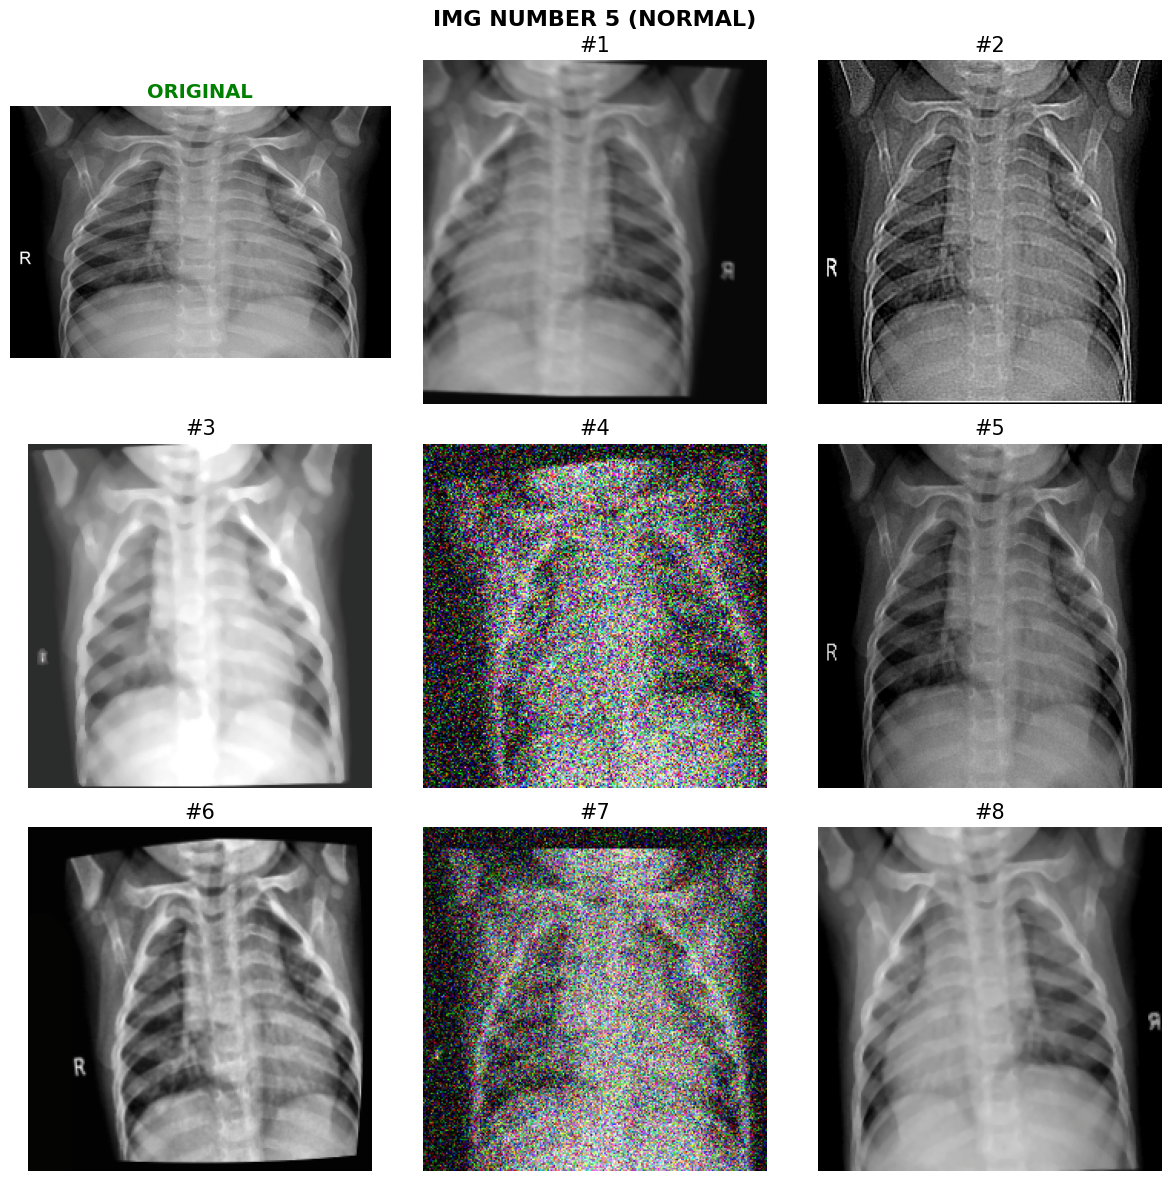


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [0, 2, 0, 1, 1, 1, 1, 2, 0, 2]
Label distribution: [8, 13, 11]


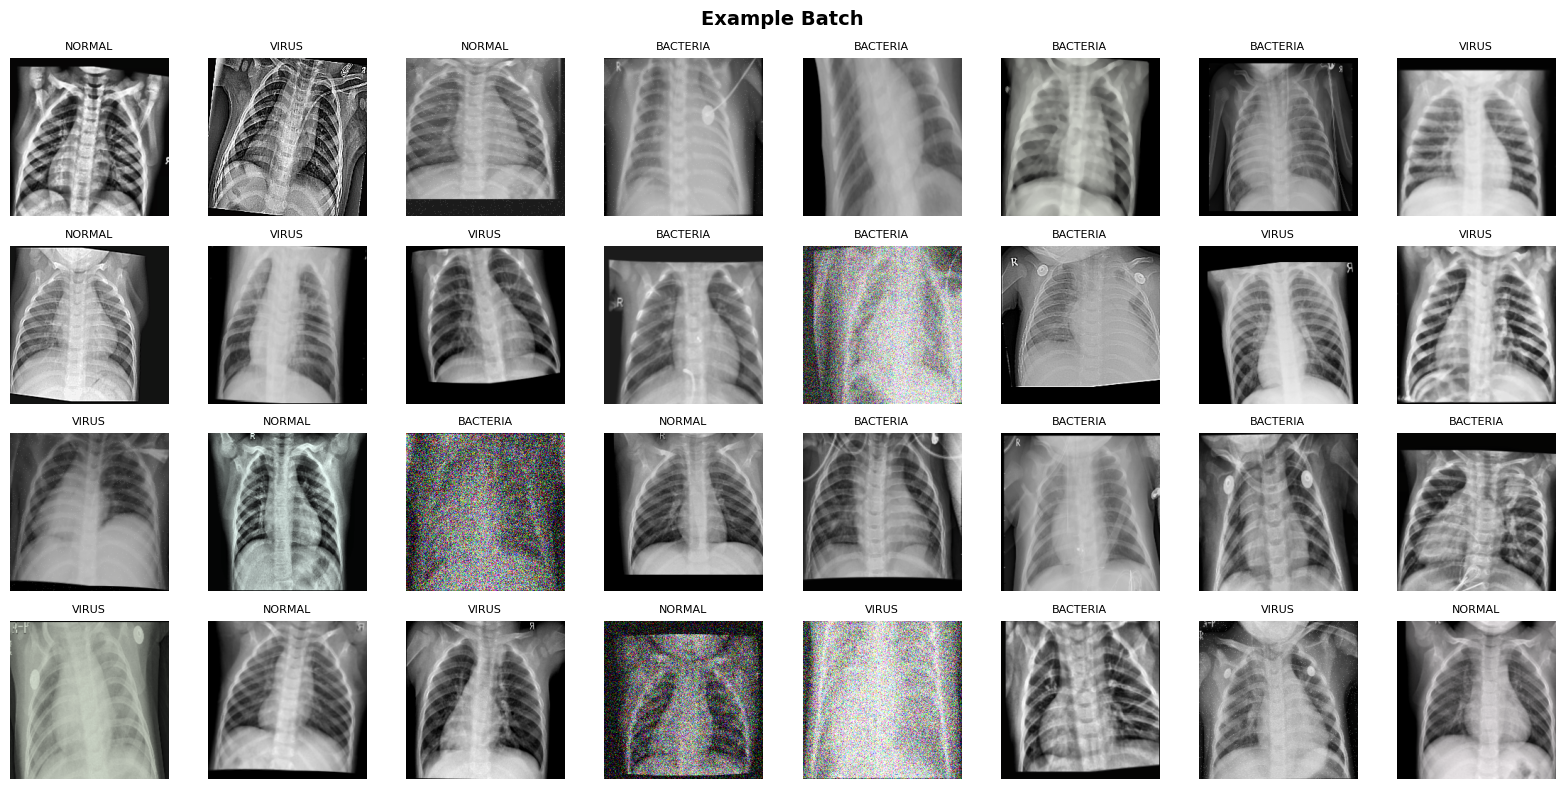

In [ ]:
# retrouver les dossiers
root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
utils_dir = os.path.join(root, "pneumonia_knn", "utils")
dimentiality_reduction_dir = os.path.join(root, "pneumonia_knn", "notebooks", "process", "dimentiality_reduction")
standard_dir = os.path.join(root, "pneumonia_knn", "notebooks", "process", "standard")
model_dir = os.path.join(root, "pneumonia_knn", "documents", "model")
visualisation_dir = os.path.join(root, "pneumonia_knn", "notebooks", "visualisation")

# charger les fichiers

# --- on_the_fly_augmentation.ipynb
spec_on_the_fly_augmentation = NotebookFinder().find_spec("on_the_fly_augmentation", [root])
on_the_fly_augmentation = importlib.util.module_from_spec(spec_on_the_fly_augmentation)
spec_on_the_fly_augmentation.loader.exec_module(on_the_fly_augmentation)

# --- pneumonia_knn\utils\dataset.ipynb
spec_utils_dataset = NotebookFinder().find_spec("dataset", [utils_dir])
utils_dataset = importlib.util.module_from_spec(spec_utils_dataset)
spec_utils_dataset.loader.exec_module(utils_dataset)

# --- pneumonia_knn\notebooks\process\standard\knn_classic.ipynb
spec_knn_classic = NotebookFinder().find_spec("knn_classic", [standard_dir])
knn_classic = importlib.util.module_from_spec(spec_knn_classic)
spec_knn_classic.loader.exec_module(knn_classic)

# --- pneumonia_knn\notebooks\process\dimentiality_reduction\knn_pca.ipynb
spec_knn_pca = NotebookFinder().find_spec("knn_pca", [dimentiality_reduction_dir])
knn_pca = importlib.util.module_from_spec(spec_knn_pca)
spec_knn_pca.loader.exec_module(knn_pca)

# --- pneumonia_knn\notebooks\process\dimentiality_reduction\knn_lda.ipynb
spec_knn_lda = NotebookFinder().find_spec("knn_lda", [dimentiality_reduction_dir])
knn_lda = importlib.util.module_from_spec(spec_knn_lda)
spec_knn_lda.loader.exec_module(knn_lda)

# --- pneumonia_knn\notebooks\visualisation\accuracy_metrics.ipynb
spec_accuracy_metrics = NotebookFinder().find_spec("accuracy_metrics", [visualisation_dir])
accuracy_metrics = importlib.util.module_from_spec(spec_accuracy_metrics)
spec_accuracy_metrics.loader.exec_module(accuracy_metrics)


  ╔════════════════════════════════════════════════════════════╗
  ║         T-DEV-810 - Analyse X-ray KNN                      ║
  ╚════════════════════════════════════════════════════════════╝

🚀 ......... Lancement de l'entraînement du modèle KNN ........
📉 KNN avec réduction avec PCA   ...


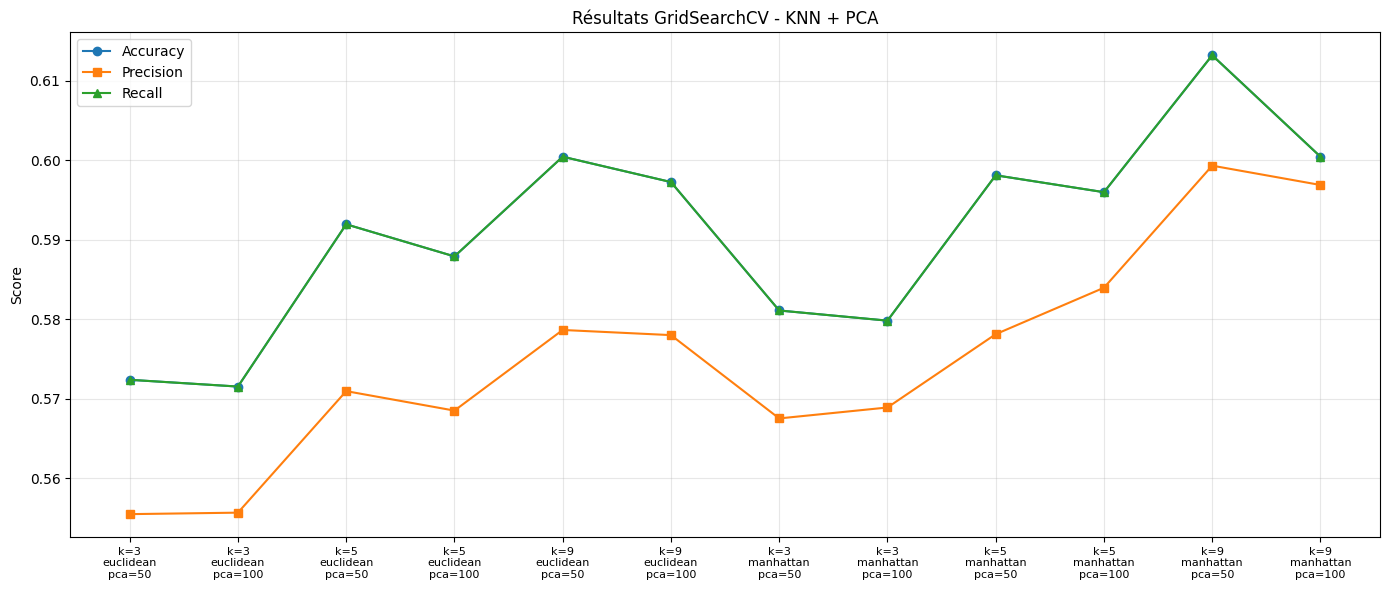

 Note : 
 recall = combien de malade l'IA a réussi à detecter en tant que malades. 
 précison = parmis ce que l'IA a detecté lesquels sont vraiment malades.
 auc = La prédiction est mesurée sur 1 (1 étant l'idéa).
Accuracy: 0.6586538461538461
✅ PCA appliquée


In [ ]:
print("""
  ╔════════════════════════════════════════════════════════════╗
  ║         T-DEV-810 - Analyse X-ray KNN                      ║
  ╚════════════════════════════════════════════════════════════╝""")

if os.path.exists(f'{model_dir}/dataset.pkl'):
  knn_model = joblib.load(f'{model_dir}/dataset.pkl')
else:
  X_train, y_train = utils_dataset.apply_dataset_to_array(on_the_fly_augmentation.train_data, "train")
  X_val, y_val = utils_dataset.apply_dataset_to_array(on_the_fly_augmentation.val_data, "val")
  X_test, y_test = utils_dataset.apply_dataset_to_array(on_the_fly_augmentation.test_data, "test")

# Entrainement modèle KNN ---------
print("\n🚀 ......... Lancement de l'entraînement du modèle KNN ........")

# KNN with PCA implementation
print("📉 KNN avec réduction avec PCA   ...")
result_pca = knn_pca.implementation_with_PCA(X_train,X_test, y_train, y_test)
print(f"Accuracy: {result_pca}")
print("✅ PCA appliquée")

# KNN with LDA implementation
print("📉 KNN avec réduction avec LDA   ...")
result_lda = knn_lda.implementation_with_LDA(y_train, X_train, X_test, y_test)
print(f"Accuracy: {result_lda}")
print("✅ LDA appliquée")

# KNN with PCA + LDA implementation


# Données des résultats
# accuracy_metrics.accuracy_visualisation(
#     ['KNN\n(sans réduction)', 'KNN + PCA\n(100 composantes)', 'KNN + LDA\n(2 composantes)'],
#     [result_pca, result_pca, result_lda],
#     ['#FF6B6B', '#4ECDC4', '#95E1D3']
# )

Ce code permet de d'organiser le processus du model KNN sans implementation et avec implementation (LDA, PCA, LDA with PCA)